**LIBRARIES IMPORTATION**

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import random

# **CALCULATING FRECUENCY OF CHARACTERS IN A TEXT**

**CHARGE TEXT**

In [148]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/Generative_AI_Experiments/main/Sources/text.txt

--2026-06-10 17:34:11--  https://raw.githubusercontent.com/LuisFelipeVelasco/Generative_AI_Experiments/main/Sources/text.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9989 (9.8K) [text/plain]
Saving to: ‘text.txt.16’

text.txt.16         100%[===================>]   9.75K  --.-KB/s    in 0s      

2026-06-10 17:34:11 (114 MB/s) - ‘text.txt.16’ saved [9989/9989]



**READ TEXT**

In [149]:
with open('text.txt', 'r') as file:
    content = file.read()
    print(content)

There is a story that runs beneath every calculation ever performed, beneath every line of code ever written, beneath every theorem ever proved. It is a story about the human need to count, to measure, to predict, and ultimately to build machines that can do all of these things faster and more reliably than any single mind. That story begins not in a university lecture hall or a computing laboratory, but in the mud and grain of ancient river valleys, where the earliest civilisations discovered that the world could be made to yield its secrets if only one found the right way to ask. Mathematics and computer science are often treated as distinct disciplines today, separated by departments and journals and professional identities. Yet the deeper one digs into the history of either field, the more clearly one sees that they are two expressions of the same underlying impulse: the desire to reduce complexity to pattern, and to harness pattern for practical ends.The earliest unambiguous evide

**CALCULATE THE FRECUENCY OF EACH CHARACTER**

In [125]:
#convert all the text in lowercase
content=content.lower()
#Replace the spaces in content with_ and the endlines with \n
content_list=list(content)

#become each character into it´s ASCII code to work with numpy
characters_ASCII=np.array([ord(char) for char in content_list])
#Remove \n character
#characters_ASCII=np.delete(characters_ASCII,np.where(characters_ASCII==10))
#Calculate the probabilities:
unique_chars,char_count=np.unique(characters_ASCII,return_counts=True)
frecuency_chars=(char_count*100)/len(characters_ASCII)


[   2 1493    3   97   12   57    8    9    1    4    3    2    2    2
    3    8    8    1  692  139  325  286  995  157  155  370  628    6
   26  380  273  621  606  180   15  483  490  802  248   85  114   21
  158    5    1]


**PLOT FRECUENCY**

([<matplotlib.axis.YTick at 0x7b6972de6de0>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9'),
  Text(0, 10, '10'),
  Text(0, 11, '11'),
  Text(0, 12, '12'),
  Text(0, 13, '13'),
  Text(0, 14, '14'),
  Text(0, 15, '15')])

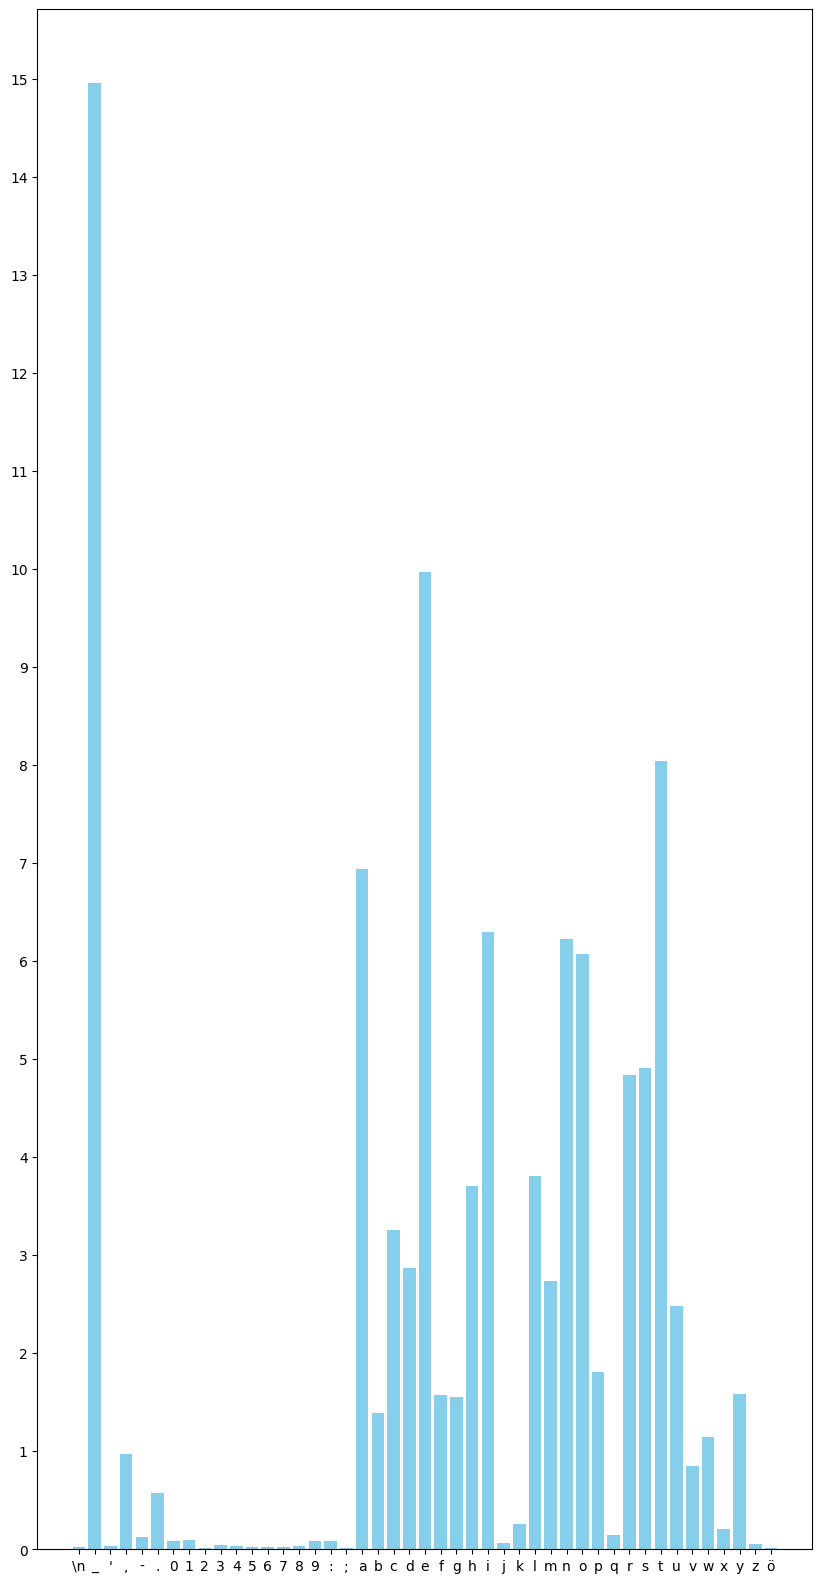

In [126]:
characters=[chr(code) for code in unique_chars]
for i,char in enumerate(characters):
    if(char=='\n'):
        characters[i]="\\n"
    if(char==' '):
        characters[i]="_"
plt.figure(figsize=(10, 20))
plt.bar(characters, frecuency_chars, color='skyblue')
plt.yticks(range(0, 16,1))

# **GENERATE RANDOM TEXT USING  USING RANDOM NUMBERS AND OCCURRENCE COUNT**  

**CHARACTER DISTRIBUTION SAMPLIN  FUNCTION**

In [140]:
from enum import unique
def sample_from_character_distribution(characters,char_count):

  """
Sample characters from a character distribution.

Parameters
----------
characters : array-like
    Characters used to determine the sample size.
char_count : numpy.ndarray
    Character occurrence counts.

Returns
-------
frequency_chars : numpy.ndarray
    Simulated character frequencies (%).
index_char : numpy.ndarray
    Indices of the sampled characters.
"""

  number_random_numbers=len(characters)
  max_random_number=len(characters)
  #Generate a np array with random numbers
  random_numbers=np.random.choice(max_random_number,number_random_numbers)
  #Generate a np array with the cumulutive sum of char_count
  char_count_sum=np.cumsum(char_count)
  #Generate a np array with the index of the char that correspond to each random number
  index_char=np.searchsorted(char_count_sum, random_numbers)
  char_random_count=np.zeros(len(unique_chars))
  unique_index_chars,index_char_counts=np.unique(index_char,return_counts=True)
  # Map the simulated frequencies back to their absolute character index positions
  char_random_count[unique_index_chars] = index_char_counts
  frecuency_chars=(char_random_count*100)/len(random_numbers)
  return frecuency_chars , index_char



**PLOT PROBABILITIES**

([<matplotlib.axis.YTick at 0x7b6972ac07a0>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9'),
  Text(0, 10, '10'),
  Text(0, 11, '11'),
  Text(0, 12, '12'),
  Text(0, 13, '13'),
  Text(0, 14, '14'),
  Text(0, 15, '15')])

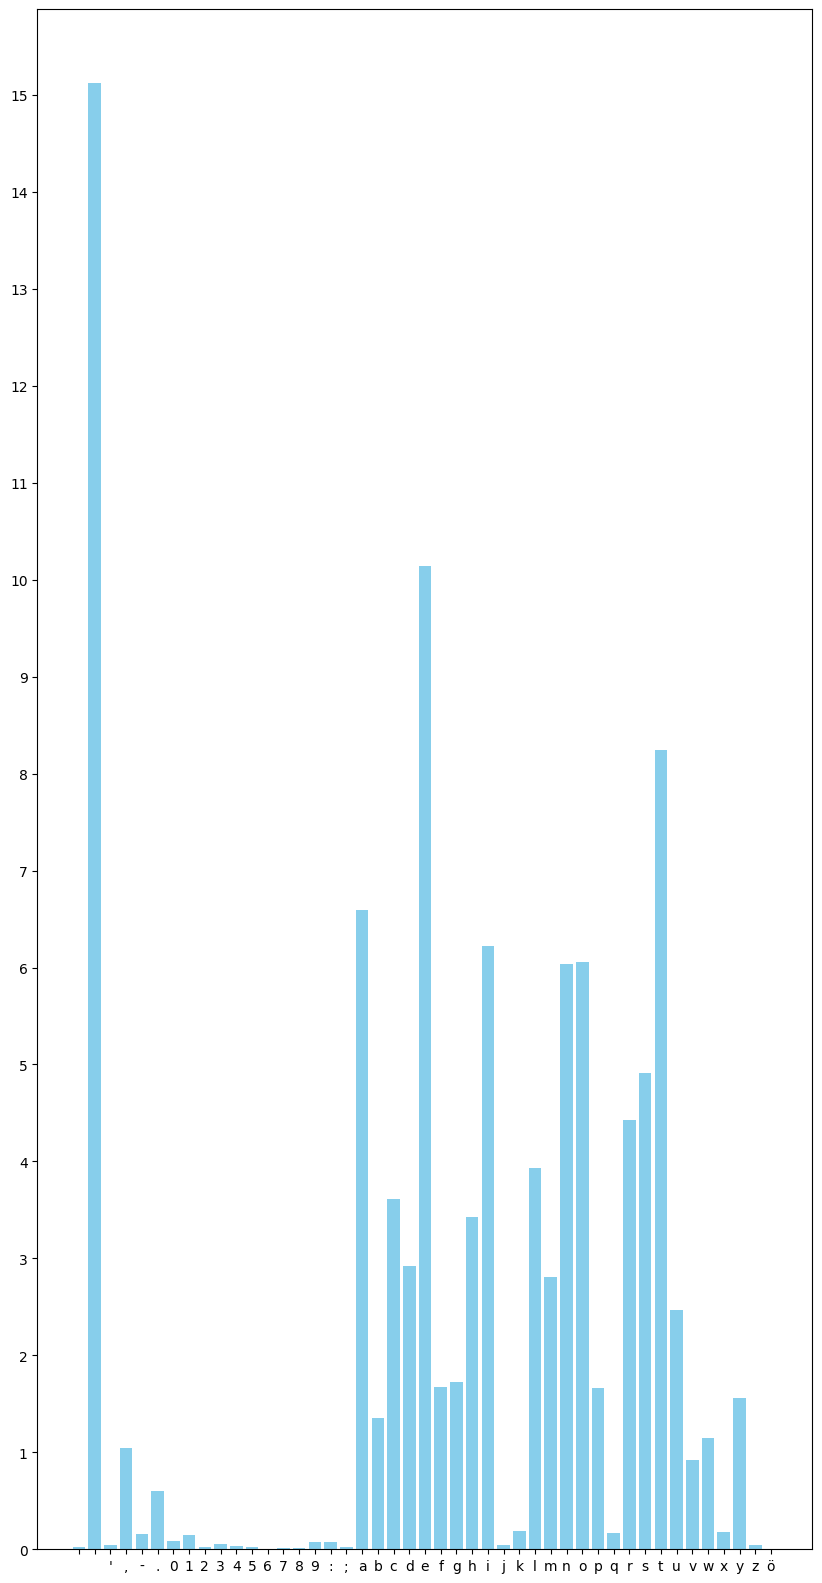

In [141]:
frecuency_chars,index_char=sample_from_character_distribution(characters_ASCII,char_count)
plt.figure(figsize=(10, 20))
plt.bar(characters, frecuency_chars, color='skyblue')
plt.yticks(range(0, 16,1))

**GENERATE RANDOM TEXT**

In [142]:
frecuency_chars,index_char=sample_from_character_distribution(characters_ASCII,char_count)
characters=np.array([chr(code) for code in unique_chars])
random_text="".join(characters[index_char])
print(random_text)

gepefitttoei hs iera retn t aeaccyulnn  msh uu owthawnwnnauvhetm  r t d  gdtre mail yr le 3n nunrgtoqpeonateeepod.orr9ruv ehzmdtr tect ln woato h- e , rer ai ocrceyaa,, trienauaabeiowlt l lo dmcygsebuomn andhemtv1    nenndtttmorfkattelehi brib,lhadcmf bi  moat aostov dta dreauoihiehriteitehnss m ahanf uhsorfu ce a to ugohri  .el w pno hcinemsmnr txo e rmaetoa tn  lraesnnittaoatcd  iirvii negpt  idro,ros eeailhne ltuer fari asaepoigoeeauia  empu eleulihe hchdmemlsd c laaiuaitaiimvaoma fae  slne tiaysog ecrnynna cuoo ct.r   secnem gosien.wwach tepn av naah'tn.mcaeewxlar iei adhlcso.cuaren st meechoeomtsrhhrlpts idcotvt rieettwngn .deitmsnwmuteixdone fe  bm n,snentcf,sdwna   iet pohr ndcu hri ntmwa gpmeceitoee.f. rlhawehoysmtth algtsieitihl aiitclehthoi l  u gei w  oeod rnegiti o sgtiht lg ehli  ae owa en1rtf tsnaa ris9eqvlnf rhi tln  p  n tyust oum eor se,d mtlsohe i lhlao ila gn o ie  tcvai iace stgoirldp hufnsnttldpeon rcnirllrtnawgoiewavrpcoeh,hmnerrthu a sm sonrneed heslooead co my,c